In [105]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [106]:
RANDOM_STATE = 42
df = pd.read_parquet("Virgo_results_cut/O3bqtransform_features.parquet")

feature_columns = [col for col in df.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df[feature_columns].to_numpy(dtype="float64")
#print(f"X.shape = {X.shape}")

X_norm = X

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
print(f"Scaled matrix: {X_scaled.shape}") 

PCA_COMPONENTS = 40

n_components = min(PCA_COMPONENTS,X_scaled.shape[0] - 1,X_scaled.shape[1])
pca = PCA(n_components=n_components,random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)
explained_variance = np.sum(pca.explained_variance_ratio_)

print(f"PCA components: {n_components}")
print(f"Explained variance: {explained_variance:.4f}")

Number of features: 1230
Scaled matrix: (8317, 1230)
PCA components: 40
Explained variance: 0.5797


In [163]:
tsne = TSNE(n_components=2,perplexity=100,early_exaggeration=700,init="pca",learning_rate="auto",random_state=RANDOM_STATE, metric='manhattan')
X_tsne = tsne.fit_transform(X_pca)

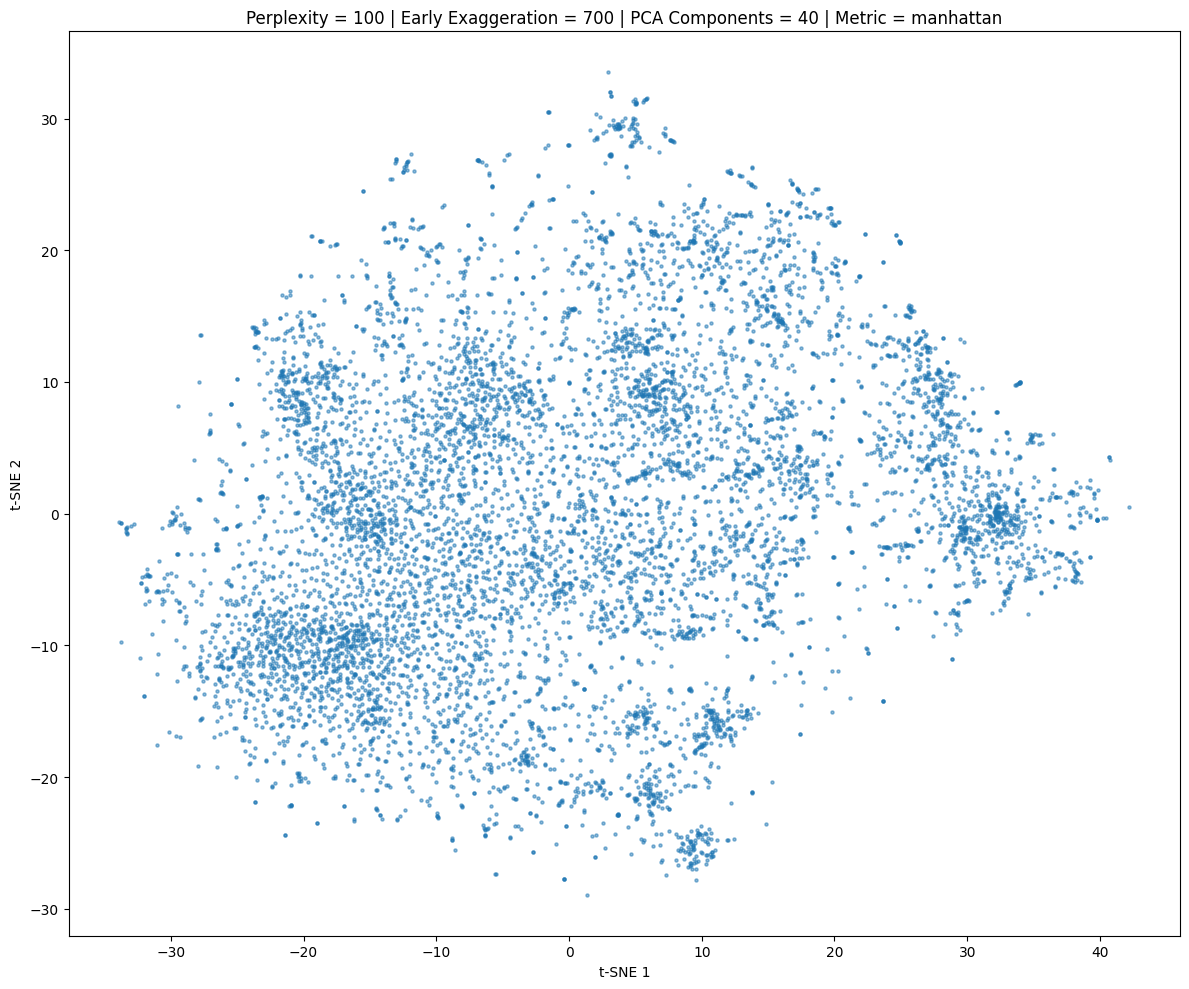

In [164]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],s=5,alpha=0.5)
ax.set_title(f"Perplexity = 100 | Early Exaggeration = 700 | PCA Components = {PCA_COMPONENTS} | Metric = manhattan")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

In [165]:
def plot_masks(df,X_tsne,column,values,figure_title,ncols=3):
    nplots = len(values)
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows,ncols,figsize=(6 * ncols, 5 * nrows),squeeze=False)
    axes = axes.flatten()
    for ax, value in zip(axes, values):
        mask = df[column] == value
        ax.scatter(X_tsne[:, 0],X_tsne[:, 1],s=5,alpha=0.10)
        ax.scatter(X_tsne[mask, 0],X_tsne[mask, 1],s=7,alpha=0.75)

        ax.set_title(f"{value}\n N = {mask.sum()}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for ax in axes[nplots:]:
        ax.remove()

    fig.suptitle(figure_title,fontsize=16)
    plt.tight_layout()
    plt.show()

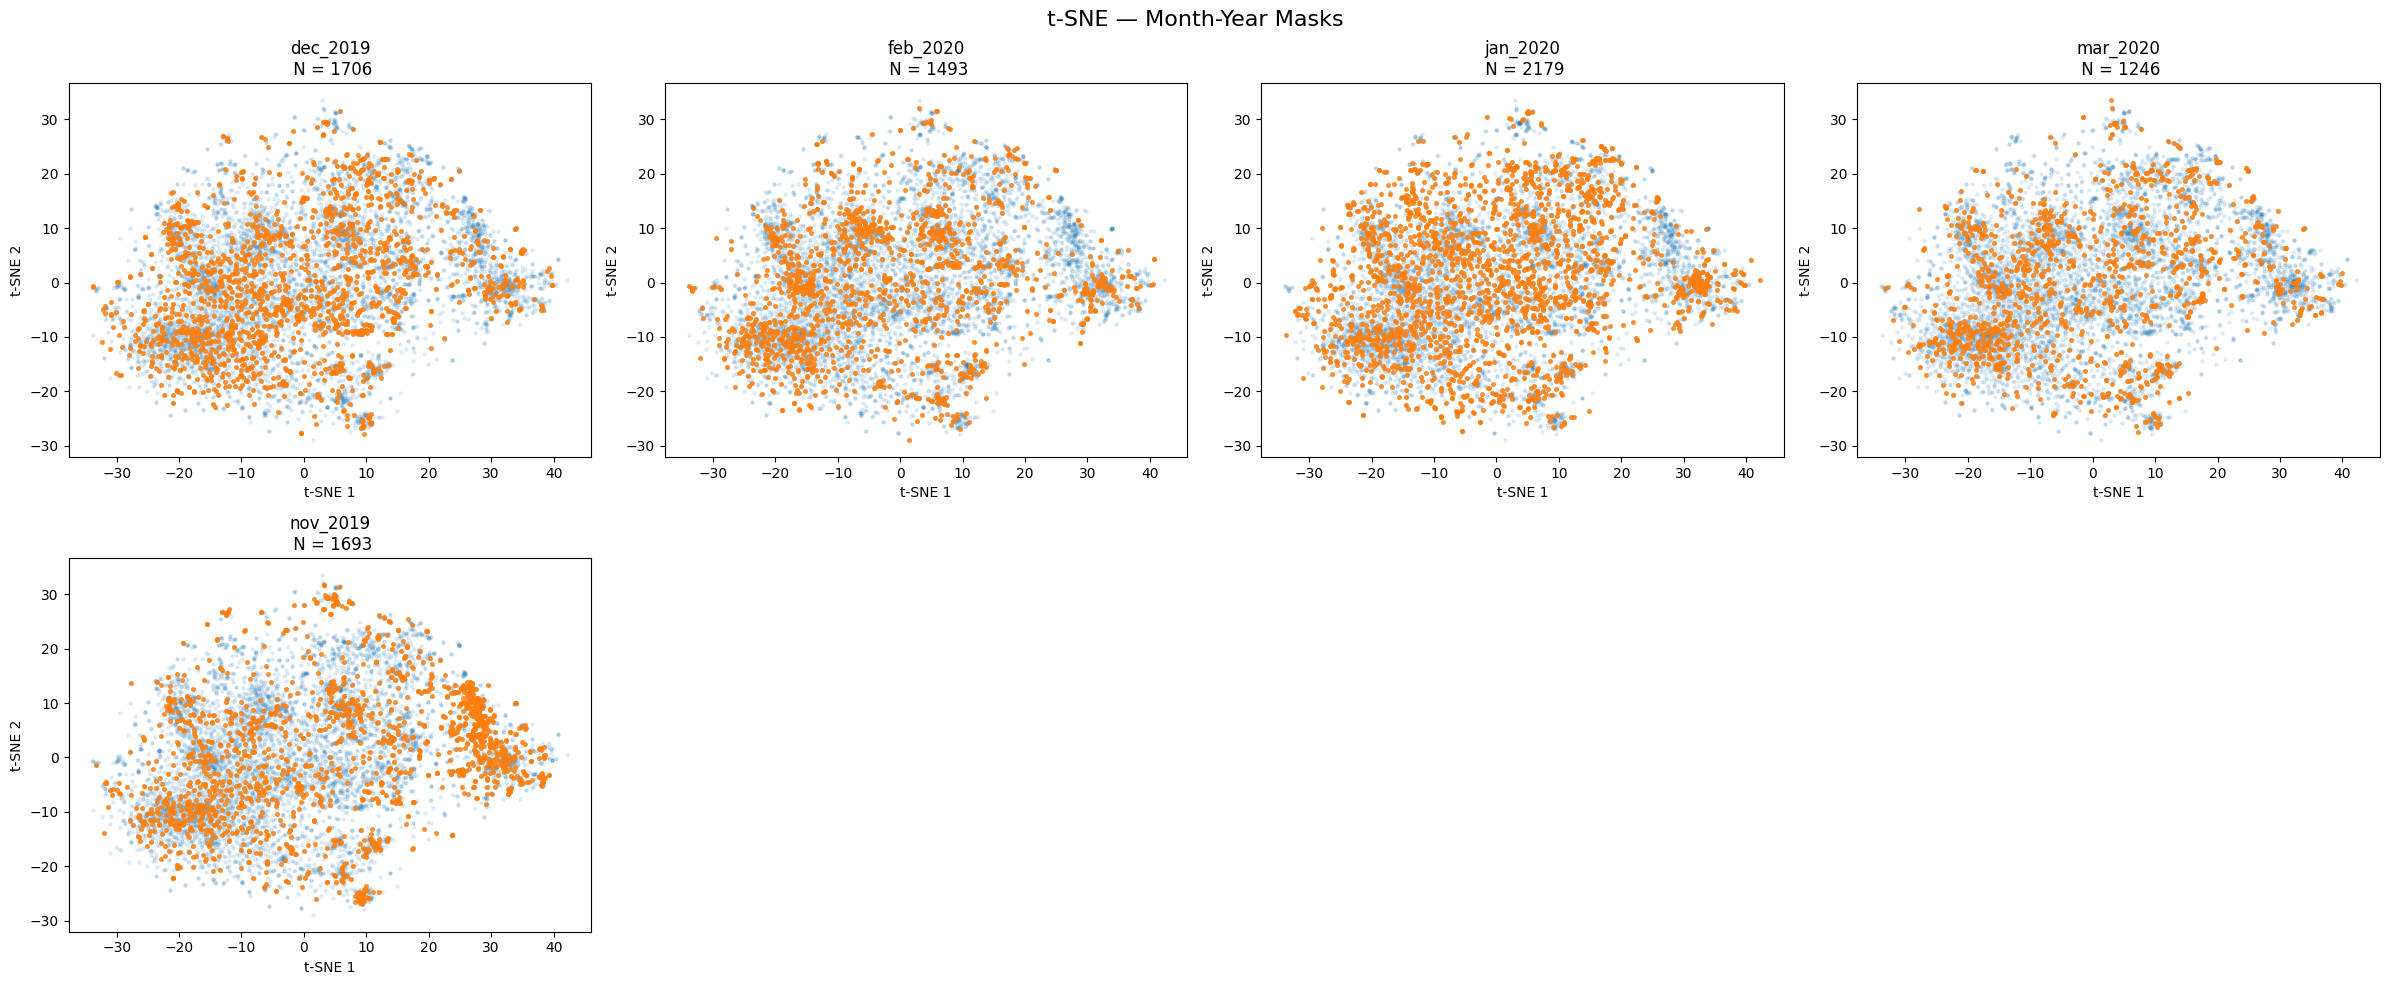

In [166]:
# Mask by month
month_year_values = sorted(df["month_year"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="month_year",values=month_year_values,figure_title="t-SNE — Month-Year Masks",ncols=4)

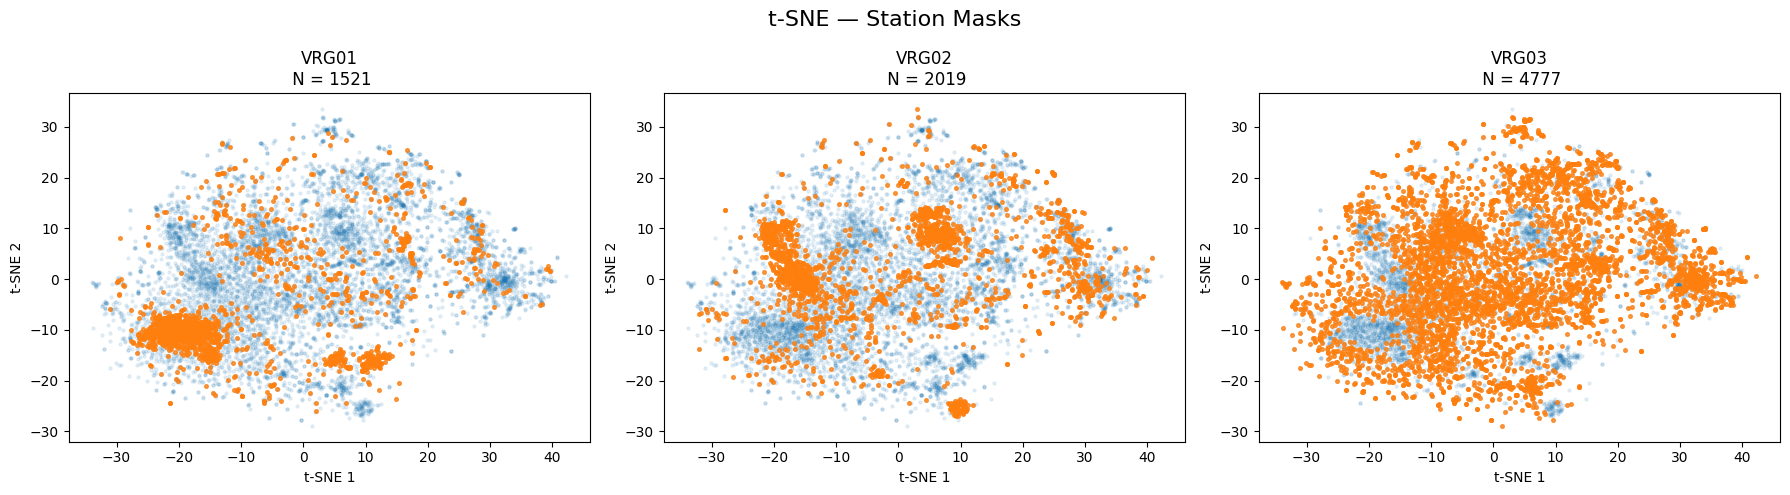

In [167]:
# Mask by station
station_values = sorted(df["station"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="station",values=station_values,figure_title="t-SNE — Station Masks",ncols=3)

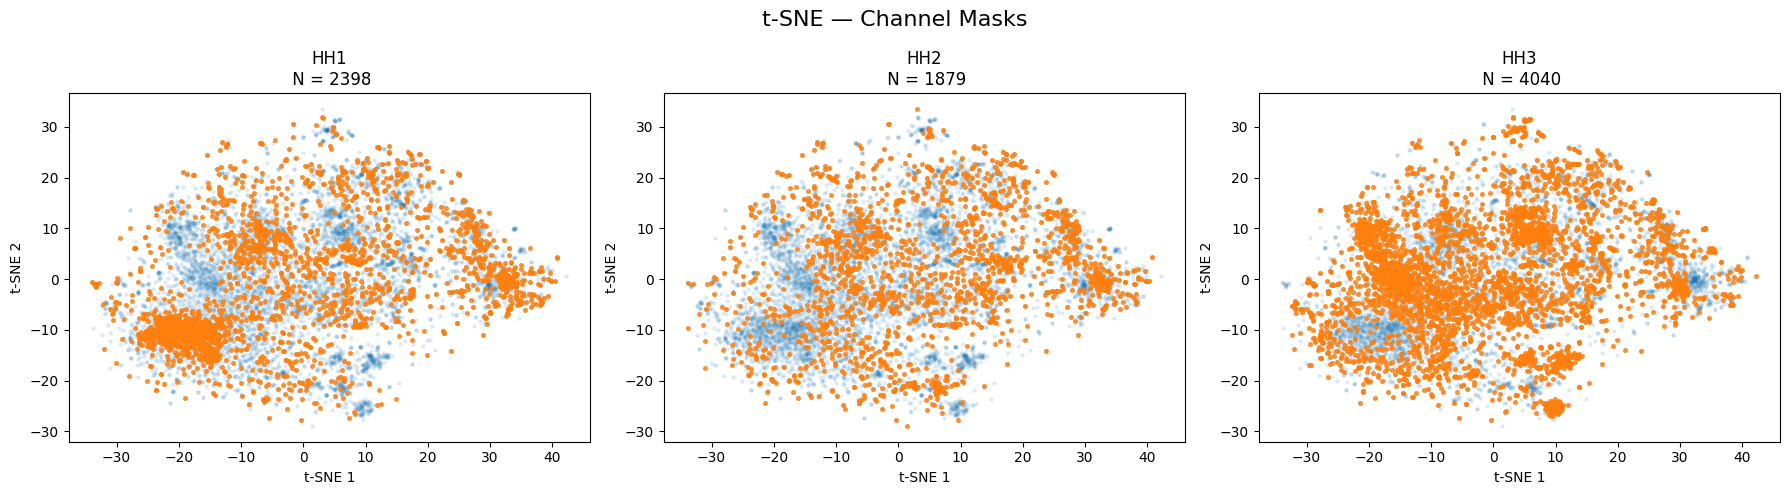

In [168]:
# Mask by channel
channel_values = sorted(df["channel"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="channel",values=channel_values,figure_title="t-SNE — Channel Masks",ncols=3)

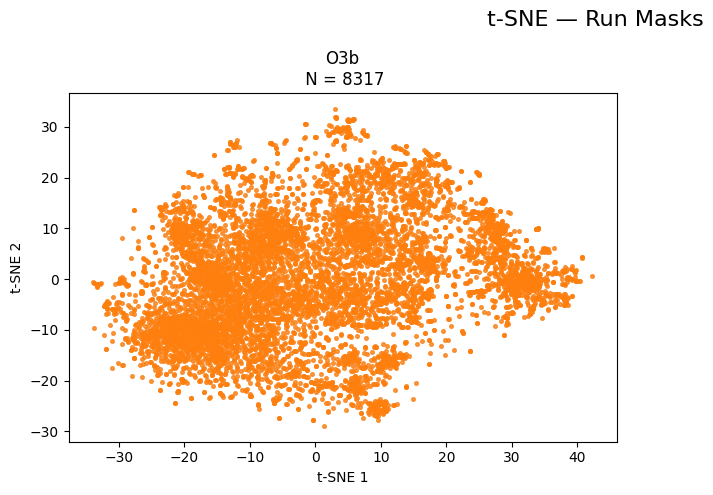

In [169]:
# Mask by run
run_values = sorted(df["run"].dropna().unique())
plot_masks(df=df,X_tsne=X_tsne,column="run",values=run_values,figure_title="t-SNE — Run Masks",ncols=2)